# Simplex-Tree Experiments on the Diabetes Dataset

**Setup.** Pima diabetes data → drop categoricals, mean-impute, scale to [0,1]. **No dimensionality
reduction:** every feature is kept and fed directly to a plain **MLP** (2 hidden layers of 64, ReLU) —
the "NN". Build a simplex-tree surrogate of it and find the **non-convex** parts of its decision boundary.

**Experiment 1.** Remove the non-convex simplices → the surrogate's **generalisation
coefficient goes up** (less overfitting), and even passes the MLP's.

**Experiment 2.** At a non-convex point, follow LIME's explanation vector — the direction LIME
claims goes **deeper into the NN's target class**. Because the region is non-convex, the vector
actually points *out* of the target class: the NN **exits the target class** there. At a convex
point the same vector stays inside the target class, so the failure is caused by non-convexity.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
import sys, os, warnings
warnings.filterwarnings('ignore')
here = os.getcwd()
project_root = os.path.abspath(here)
while project_root != os.path.dirname(project_root) and not os.path.isdir(os.path.join(project_root, 'in2D')):
    project_root = os.path.dirname(project_root)
for p in (project_root, here):
    if p not in sys.path:
        sys.path.insert(0, p)

from simplex_tree_classifier import SimplexTreeClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

import pickle as _pickle
CACHE_DIR = os.path.join(os.getcwd(), 'models')
def cache_load(name):
    """Return the object cached under models/<name>, or None if absent."""
    p = os.path.join(CACHE_DIR, name)
    if os.path.exists(p):
        with open(p, 'rb') as _f:
            obj = _pickle.load(_f)
        print(f'cache hit  <- {p}')
        return obj
    return None
def cache_save(name, obj):
    """Pickle obj to models/<name> and return it."""
    os.makedirs(CACHE_DIR, exist_ok=True)
    p = os.path.join(CACHE_DIR, name)
    with open(p, 'wb') as _f:
        _pickle.dump(obj, _f)
    print(f'cache save -> {p}')
    return obj

device: cpu


### 1. Load & preprocess

Drop categoricals, mean-impute the 0-placeholder values, scale to [0,1], target → +1/-1.


In [2]:
diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
df = diabetes.data.copy()
y_raw = diabetes.target

# # (a) drop categorical columns
# cat_cols = [c for c in df.columns if str(df[c].dtype) in ('category', 'object')]
# df = df.drop(columns=cat_cols)
# print(f'Categorical columns dropped: {cat_cols if cat_cols else "(none)"}')

# (b) mean imputation: 0 is a missing-value placeholder for these features
for col in ['plas', 'pres', 'skin', 'insu', 'mass']:
    if col in df.columns:
        m = df[col] == 0
        if m.sum() > 0:
            df.loc[m, col] = df.loc[~m, col].mean()
df = df.dropna()

all_feature_names = list(df.columns)
feature_names = all_feature_names
X_all = MinMaxScaler().fit_transform(df.values.astype(np.float64))   # (c) normalise to [0,1]
y = np.where(y_raw.loc[df.index] == 'tested_positive', 1.0, -1.0)     # (d) +1 / -1

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

n_features = X_train.shape[1]

LEAF_BUDGET = 8000
SUBDIVISION_LEVELS = 4

print(f'Features (all {n_features} kept): {feature_names}')
print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)}')
print(f'Feature range: [{X_train.min():.2f}, {X_train.max():.2f}]')

Features (all 8 kept): ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
768 samples | Train 614 | Test 154
Feature range: [0.00, 1.00]


### 2. Train the MLP

All raw features → feed-forward MLP (2 hidden layers of 64, ReLU) → sigmoid. First define the model + trainer, look at the learning curve to choose the epoch / LR budget, then fit the model the rest of the notebook uses.

In [3]:
class DiabetesMLP(nn.Module):
    def __init__(self, d, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        if x.dim() > 2:
            x = x.reshape(x.shape[0], -1)   # accept (batch, d, 1) too
        return torch.sigmoid(self.fc(self.net(x)))


def train_nn(model, X_tr, y_tr, X_val, y_val, epochs=300, lr=0.01, batch_size=64):
    y_tr01  = ((y_tr  + 1) / 2).astype(np.float32)
    y_val01 = ((y_val + 1) / 2).astype(np.float32)
    ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                       torch.tensor(y_tr01, dtype=torch.float32).unsqueeze(1))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    crit, opt = nn.BCELoss(), optim.Adam(model.parameters(), lr=lr)
    # LR decay on a validation plateau: when val accuracy stops improving for `patience`
    # epochs, halve the LR. This calms the late-epoch spikes. The reduction is driven by
    # the (deterministic) val-accuracy sequence, so the 300-epoch curve and the 200-epoch
    # model still share the same trajectory for epochs 0-199.
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=10)
    best, best_state, best_ep = 0.0, None, 0
    loss_history, val_acc_history = [], []
    for ep in range(epochs):
        model.train()
        ep_loss, n_batches = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            ep_loss += float(loss.detach()); n_batches += 1
        loss_history.append(ep_loss / max(n_batches, 1))   # mean training loss this epoch
        model.eval()
        with torch.no_grad():
            vp = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        va = accuracy_score(y_val01, (vp >= 0.5).astype(float))
        val_acc_history.append(va)
        sched.step(va)                        # plateau scheduler steps on the val metric
        if va > best:
            best, best_state, best_ep = va, {k: v.cpu().clone() for k, v in model.state_dict().items()}, ep
    model.load_state_dict(best_state)
    model.loss_history = loss_history
    model.val_acc_history = val_acc_history
    print(f'Best validation accuracy: {best:.4f} (epoch {best_ep + 1}/{epochs})')
    return model


def nn_predict(model, X_np):
    """Hard MLP labels (+1 / -1) for a batch of points."""
    model.eval()
    with torch.no_grad():
        p = model(torch.tensor(X_np, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    return np.where(p >= 0.5, 1.0, -1.0)


Best validation accuracy: 0.7857 (epoch 38/300)


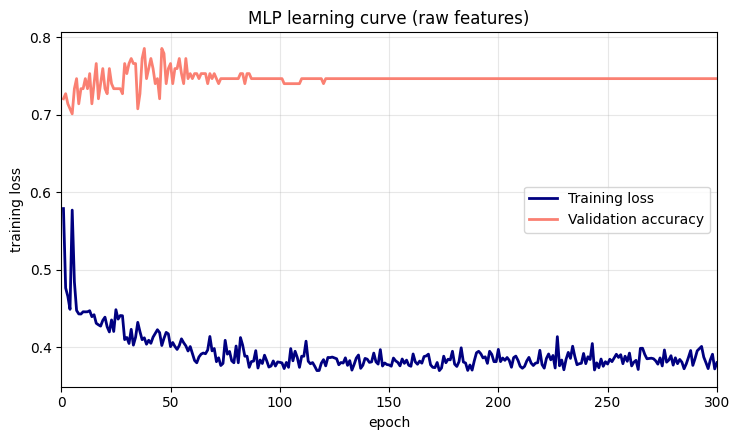

In [ ]:
# EXPLORE before committing:
CURVE_EPOCHS, CURVE_LR, CURVE_BATCH = 300, 0.01, 32
torch.manual_seed(42); np.random.seed(42)
curve_model = DiabetesMLP(n_features, hidden=64).to(device)
train_nn(curve_model, X_train, y_train, X_test, y_test,
         epochs=CURVE_EPOCHS, lr=CURVE_LR, batch_size=CURVE_BATCH)
loss_history = curve_model.loss_history
accuracy_history = curve_model.val_acc_history ### TODO: check if this is the right accuracy and print it on the x axis train + test accuracy


epochs_axis = range(1, len(loss_history) + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(epochs_axis, loss_history, color='navy', lw=2, label='Training loss')
ax.plot(epochs_axis, accuracy_history, color='salmon', lw=2, label='Validation accuracy')
ax.set_xlim(0, CURVE_EPOCHS); ax.set_xlabel('epoch'); ax.set_ylabel('training loss')
ax.set_title('MLP learning curve (raw features)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Fit the MLP the notebook uses

With the learning curve above, set the epoch / learning-rate budget below and train the model the rest of the notebook relies on (cached to `models/diabetes_mlp_raw.pt`).

In [5]:
# Fit the model the notebook uses. Copy the epoch / LR budget you settled on from the
# learning curve above. Loads models/diabetes_mlp_raw.pt if present; delete that file to
# retrain after changing these.
EPOCHS, LR, BATCH = 200, 0.01, 32
torch.manual_seed(42); np.random.seed(42)
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'diabetes_mlp_raw.pt')
nn_loaded = os.path.exists(model_path)
nn_model = DiabetesMLP(n_features, hidden=64).to(device)
if nn_loaded:
    ckpt = torch.load(model_path, map_location=device)
    nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
    if ckpt.get('loss_history') is not None:
        nn_model.loss_history = ckpt['loss_history']
    print(f'Loaded NN <- {model_path}')
else:
    nn_model = train_nn(nn_model, X_train, y_train, X_test, y_test,
                        epochs=EPOCHS, lr=LR, batch_size=BATCH)

nn_test_acc = accuracy_score(y_test, nn_predict(nn_model, X_test))
print(f'MLP test accuracy: {nn_test_acc:.4f}')

# Save (state_dict + config to rebuild). Reload with:
#   ckpt = torch.load(model_path, map_location=device)
#   nn_model = DiabetesMLP(**ckpt['config']).to(device)
#   nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
if nn_loaded:
    print(f'NN loaded from cache; not re-saving ({model_path})')
else:
    os.makedirs(MODEL_DIR, exist_ok=True)
    torch.save({
        'class': type(nn_model).__name__,
        'state_dict': nn_model.state_dict(),
        'config': dict(d=n_features, hidden=64),
        'feature_names': globals().get('feature_names'),
        'loss_history': getattr(nn_model, 'loss_history', None),
    }, model_path)
    print(f'Saved NN -> {model_path}')

Loaded NN <- /home/yasmin/SimplexTreeClassifier/in2D/experiments_with_package/models/diabetes_mlp_raw.pt
MLP test accuracy: 0.8247
NN loaded from cache; not re-saving (/home/yasmin/SimplexTreeClassifier/in2D/experiments_with_package/models/diabetes_mlp_raw.pt)


### 3. Build the simplex-tree surrogate

Fill [0,1]^d with random points, label them with the MLP, and fit a SimplexTree (local
linear classifiers) to copy the MLP's decision surface. Real train points are added so both
classes appear.

In [6]:
# TODO:s 
#   [DONE]  "do i need the data here? i'm already creating data in the constructor"
#           -> no manual X_fill: surrogate mode samples the fill itself (n_fill
#              points, seeded by random_state), so np.random.seed(42) is gone.

#   [DONE]  "model=nn_model -- this should be in the constructor, mode surrogate"
#           -> the model is now passed to the constructor => surrogate mode.

#   [DONE]  "check if i'm getting data; if normalized ok, else raise an exception"
#           -> the package now raises if normalize=False and data isn't in [0,1]
#              (SimplexTreeClassifier._ensure_in_unit_cube), enforced inside fit().

#   [DONE]  "either the data or the model should be given in the constructor, so
#            nn_predict() should not be done here"
#           -> surrogate mode: the model labels the fill; no manual nn_predict here.

#   [CHECK] "check with margin" -> kept margin=0.0 (matches the old runs). Raise it
#           slightly only if [0,1]^d corner points ever fall outside the simplex.


N_FILL, C_PARAM = 5000, 10000

stc = cache_load('diabetes_stc_raw.pkl')
if stc is None:
    stc = SimplexTreeClassifier(
        model= nn_model,      # -> surrogate mode
        n_features=n_features, n_fill=N_FILL,
        margin=0.0,                                   # normalize auto-False in surrogate mode
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS,
        random_state=42,
    )
    stc.fit()                   # X_train appended to the fill set; the model labels everything
    # stc.model = None          # drop the (unpicklable) lambda; not needed after fit / for caching
    cache_save('diabetes_stc_raw.pkl', stc)

# the surrogate training set the package built for us (fill points + X_train, NN-labeled)
X_fill, y_fill = stc.training_data_

print(f'Surrogate training points: {len(X_fill)}  (+1={int((y_fill==1).sum())}, -1={int((y_fill==-1).sum())})')
print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Surrogate agreement with NN  - on fill points: {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Surrogate agreement with NN  - on test points: {accuracy_score(nn_predict(nn_model, X_test), stc.predict(X_test)):.4f}')
print(f'Surrogate accuracy - on test points: {accuracy_score(y_test, stc.predict(X_test)):.4f}')
print(f'NN_model accuracy - on test points: {accuracy_score(y_test, nn_predict(nn_model, X_test)):.4f}')


cache hit  <- /home/yasmin/SimplexTreeClassifier/in2D/experiments_with_package/models/diabetes_stc_raw.pkl
Surrogate training points: 5614  (+1=2281, -1=3333)
Surrogate leaves: 6561
Surrogate agreement with NN  - on fill points: 0.8491
Surrogate agreement with NN  - on test points: 0.8052
Surrogate accuracy - on test points: 0.7338
NN_model accuracy - on test points: 0.8247


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus a neighbour.
`epsilon` sets strictness (smaller = only severe curvature).

In [7]:
# EPSILON: barycentric centroid fraction 1/(d+1) -- the package's own geometric
# default, so no hand-tuned probe-placement number.
EPSILON = 1.0 / (n_features + 1)

# REMOVAL_FACTOR from the DATA, not a magic number: one threshold-free pass returns
# every bend's depth (offset / shared-face length); keep the deepest quartile (bends
# past the 75th percentile). Since epsilon scales all depths together, this quantile
# cut is essentially invariant to the exact epsilon above.
_bend_depths = stc.find_nonconvex_leaves(criterion='distance', epsilon=EPSILON, removal_factor=0.0)
_dvals = np.fromiter(_bend_depths.values(), dtype=float)
REMOVAL_FACTOR = float(np.quantile(_dvals, 0.75)) if _dvals.size else 0.0

# _nc = cache_load('diabetes_nonconvex_raw.pkl')
# if _nc is None:
nonconvex_keys = {k for k, v in _bend_depths.items() if v > REMOVAL_FACTOR}
n_crossing = len(stc.identify_crossing_simplices())
cache_save('diabetes_nonconvex_raw.pkl',
            dict(nonconvex_keys=nonconvex_keys, n_crossing=n_crossing))
# else:
#     nonconvex_keys, n_crossing = _nc['nonconvex_keys'], _nc['n_crossing']
    
print(f'Boundary-crossing simplices : {n_crossing}')
print(f'Non-convex simplices        : {len(nonconvex_keys)}  (epsilon={EPSILON:.3f}, removal_factor={REMOVAL_FACTOR:.3f})')


def leaf_key_for_point(stc_model, x):
    """Frozenset key of the leaf simplex containing point x (or None)."""
    leaf = stc_model.tree.find_containing_simplex(tuple(x))
    return frozenset(leaf.vertex_indices) if leaf is not None else None


test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


cache save -> /home/yasmin/SimplexTreeClassifier/in2D/experiments_with_package/models/diabetes_nonconvex_raw.pkl
Boundary-crossing simplices : 6561
Non-convex simplices        : 1640  (epsilon=0.111, removal_factor=0.041)
Test points inside a non-convex region: 45 / 154


## Experiment 1 — Non-convex removal reduces overfitting

The surrogate copies the MLP from the fill points; with too many leaves it **overfits**.
We remove the non-convex simplices and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher} = \text{less overfitting}).$$

Two views: faithfulness to the MLP (test ÷ fill agreement), and — the headline — the same
true-label metric for the MLP and the surrogate, so they compare directly.

In [8]:
import copy

# [DONE] ### TODO: use the STC i created earlier and use the package to preform "trim" method (ofc after i should see that less points are in nonconvex area (cell 4))

if 'stc_convex' not in globals():
    stc_convex = copy.deepcopy(stc)
    before = len(stc_convex.tree.get_leaves())
    removed = stc_convex.remove_nonconvex_leaves(
        criterion='distance', epsilon=EPSILON, removal_factor=REMOVAL_FACTOR, # [DONE] ### # TODO: check if better to use distance than convexity_sign and purpose of convexity_sign
        max_remove_frac=0.45,     
        max_iter=50)
    print(f'Convex trim: {before} -> {len(stc_convex.tree.get_leaves())} leaves (removed {removed})')
print(f'Pruned surrogate leaves: {len(stc_convex.leaf_simplexes)}')

Convex trim: 6561 -> 3609 leaves (removed 2952)
Pruned surrogate leaves: 3609


In [9]:
y_nn_test = nn_predict(nn_model, X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))   # fit on fill distribution
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))   # faithfulness on held-out
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))   # accuracy vs true labels
    return train_agree, test_agree, train_agree - test_agree, test_agree / train_agree, true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  ({c_gc - b_gc:+.4f}, '
      f'{"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  ({c_acc - b_acc:+.4f})')

                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                               6561                 3609
Train agreement (vs NN)            0.8491               0.8199
Test  agreement (vs NN)            0.8052               0.7987
Generalisation coef.               0.9483               0.9741
Test accuracy (vs labels)          0.7338               0.7403

Generalisation coefficient: 0.9483 -> 0.9741  (+0.0259, IMPROVED)
Test accuracy vs labels  : 0.7338 -> 0.7403  (+0.0065)


## Check if nonconvex leaves number is reduced 

In [10]:
# Compare against the ORIGINAL stc set (`nonconvex_keys`, from the "Find non-convex
# regions" cell). Use a DISTINCT name here so we don't clobber it -- otherwise the
# Experiment-2 cell below would compare stc_convex against itself.
nonconvex_keys_pruned = set(stc_convex.find_nonconvex_leaves(criterion='distance', epsilon=EPSILON, removal_factor=REMOVAL_FACTOR).keys())
n_crossing = len(stc_convex.identify_crossing_simplices())

print(f'Boundary-crossing simplices : {n_crossing}')
print(f'Non-convex simplices (pruned): {len(nonconvex_keys_pruned)}  (epsilon={EPSILON:.3f}, removal_factor={REMOVAL_FACTOR:.3f})')
print(f'Reduced: original stc={len(nonconvex_keys)}  ->  pruned stc_convex={len(nonconvex_keys_pruned)}')


Boundary-crossing simplices : 3609
Non-convex simplices (pruned): 231  (epsilon=0.111, removal_factor=0.041)
Reduced: original stc=1640  ->  pruned stc_convex=231


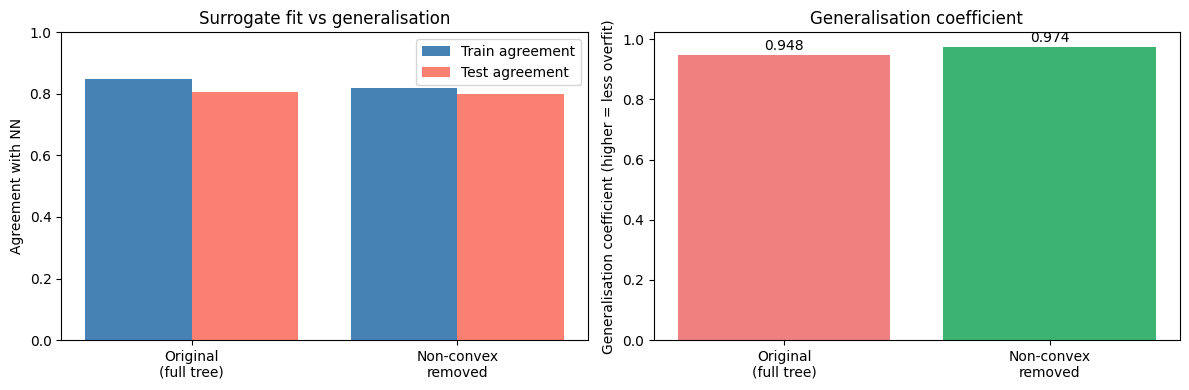

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## Experiment 2 -- LIME is faithful on the pruned surrogate but not on the NN

Take a point $x_0$ in a region where the **NN is non-convex** (found via the simplex tree) and compare
LIME's explanation of the **NN** with LIME's explanation of our **pruned simplex-tree surrogate**
(`stc_convex`, after non-convex removal) at the *same* point. For each model we fit LIME at $x_0$ for
the target class (the class the NN predicts there), read the direction LIME says increases that class,
and step along it while tracking the model's *true* $P(\text{target})$:

- **NN:** LIME claims $P(\text{target})$ only grows, but following that direction the NN's prediction
  **crosses the decision boundary** -- its argmax leaves the target class and $P(\text{target})$
  collapses. LIME's linear explanation is unfaithful here.
- **Pruned surrogate:** at the same point the surrogate is locally convex (the bend was removed), so
  $P(\text{target})$ **rises and the prediction stays in the target class** -- no crossing, LIME is
  faithful.

The **primary quantitative result** (aggregate local fidelity over all non-convex points) follows the
illustration below.

In [12]:
try:
    import lime, lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime, lime.lime_tabular

def nn_predict_proba(X_):
    """[P(neg), P(pos)] from the single-sigmoid NN."""
    arr = np.atleast_2d(np.asarray(X_, dtype=np.float32))
    nn_model.eval()
    with torch.no_grad():
        p = nn_model(torch.tensor(arr).to(device)).cpu().numpy().reshape(-1)
    return np.column_stack([1 - p, p])

def nn_proba(X_):
    return nn_predict_proba(X_)                      # [P(neg), P(pos)]

n_classes = int(nn_proba(X_train[:1]).shape[1])
if 'class_names' not in globals():
    class_names = [str(c) for c in range(n_classes)]

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def stc_proba(X_):
    """SMOOTH probabilities for the pruned surrogate: softmax of its one-vs-rest
    decision_function (smooth, so LIME can fit a meaningful local linear model)."""
    X_ = np.atleast_2d(np.asarray(X_, dtype=np.float64))
    d = np.asarray(stc_convex.classifier.decision_function(stc_convex.transform(X_)))
    if d.ndim == 1:
        d = np.column_stack([-d, d])
    return _softmax(d)

_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train, mode='classification', feature_names=list(feature_names),
    class_names=[str(c) for c in range(n_classes)],
    discretize_continuous=False, random_state=0)
ALPHA = np.linspace(0, 0.4, 81)    # LOCAL step: LIME's linear model is only
#                                    trustworthy near x0, so we compare the two
#                                    models over a short local move, not a long one.

def _lime_dir(point, proba_fn, target, num_samples=3000):
    _lime_explainer.random_state = np.random.RandomState(0)   # reproducible direction (search == readout == plot)
    exp = _lime_explainer.explain_instance(point, proba_fn, num_features=n_features,
                                           num_samples=num_samples, labels=(target,))
    coef = np.zeros(n_features)
    for i, w in exp.local_exp[target]:
        coef[i] = w
    intercept = exp.intercept[target]
    mean_, scale_ = _lime_explainer.scaler.mean_, _lime_explainer.scaler.scale_
    def lime_p(x):
        xs = (np.atleast_2d(x) - mean_) / scale_
        return intercept + xs.dot(coef)
    grad = coef / scale_
    return coef, lime_p, grad

def push(point, proba_fn, target=None):
    """Fit LIME to `proba_fn` at `point`, then step along the direction LIME says
    increases P(target) (target defaults to the model's argmax at the point).
    Returns alphas, P(target), LIME P(target), target, w, unit d, argmax path."""
    point = np.asarray(point, dtype=np.float32)
    if target is None:
        target = int(np.argmax(proba_fn(point)[0]))
    coef, lime_p_fn, grad = _lime_dir(point, proba_fn, target)
    d = grad / max(np.linalg.norm(grad), 1e-12)
    xs = np.clip(point + np.outer(ALPHA, d), 0, 1)
    P = proba_fn(xs)
    return ALPHA, P[:, target], np.clip(lime_p_fn(xs), 0, 1), target, coef, d, np.argmax(P, axis=1)

def crosses_boundary(argmax_path, target):
    """True if the model's argmax LEAVES the target class anywhere on the path."""
    return bool((np.asarray(argmax_path) != target).any())

def first_crossing(argmax_path, target):
    """Index of the first step where the argmax leaves the target class, else None."""
    off = np.where(np.asarray(argmax_path) != target)[0]
    return int(off[0]) if off.size else None


In [13]:

if 'nonconvex_keys' not in globals():
    nonconvex_keys = set(stc.find_nonconvex_leaves(criterion='distance', epsilon=EPSILON, removal_factor=REMOVAL_FACTOR).keys())
# Regions still flagged non-convex in the PRUNED surrogate (used by the readout cell).
nonconvex_keys_convex = set(stc_convex.find_nonconvex_leaves(
    criterion='distance', epsilon=EPSILON, removal_factor=REMOVAL_FACTOR).keys())

# TWO demo points, each chosen for ONE job -- they need NOT be the same point:
#   x0_nn : inside a REMOVED non-convex simplex, the NN clearly STARTS in its target class
#           but following LIME's own "increase target" direction the NN LEAVES that class
#           (crosses, ideally in-and-out). This is LIME's MISTAKE, caused by non-convexity.
#   x0_stc: in a formerly-non-convex, now-pruned region, the surrogate STARTS in its class
#           and following LIME STAYS there -- no mistake, because the non-convex split was
#           removed. Defaults to x0_nn when that same point already works.
# We probe points spread across the removed simplices (centroid, vertices, edge midpoints,
# random interior mixes, nudged strictly inside) and fit LIME on each model.
if 'x0_nn' not in globals() or x0_nn is None:
    _stc_leaves  = {frozenset(l.vertex_indices): l for l in stc.tree.get_leaves()}
    _convex_keys = {frozenset(l.vertex_indices) for l in stc_convex.tree.get_leaves()}
    removed_keys = [k for k in nonconvex_keys if k in _stc_leaves and k not in _convex_keys]
    print(f'removed non-convex simplices: {len(removed_keys)}   '
          f'(original nc={len(nonconvex_keys)}, pruned nc={len(nonconvex_keys_convex)})')

    _rng   = np.random.default_rng(0)
    P_MIN  = 0.60    # a demo point must START clearly inside its class (not at ~0.5 on the boundary)
    P_SAT  = 0.985   # ... but not saturated, or there is no room to bend and cross
    BUDGET = 80      # LIME is slow; cap how many candidates we fit

    def _simplex_probe_points(V):
        V = np.asarray(V, dtype=np.float64); c = V.mean(0)
        pts = [c] + list(V)
        for a in range(len(V)):
            for b in range(a + 1, len(V)):
                pts.append(0.5 * (V[a] + V[b]))
        pts += list(_rng.dirichlet(np.ones(len(V)), size=8) @ V)
        pts = 0.9 * np.asarray(pts, dtype=np.float64) + 0.1 * c   # keep strictly inside the leaf
        return pts.astype(np.float32)

    # Probe points that START clearly (but not saturated) in the NN's class; test those in a
    # "clearly in target yet bendable" sweet spot (P ~ 0.75) first.
    probes = []
    for k in removed_keys:
        S = _simplex_probe_points(_stc_leaves[k].vertices)
        for x, s in zip(S, nn_proba(S).max(axis=1)):
            if P_MIN <= s <= P_SAT:
                probes.append((float(s), x))
    probes.sort(key=lambda t: abs(t[0] - 0.75))
    print(f'candidate points starting clearly in the NN class: {len(probes)}')

    # x0_nn: NN starts in target AND LIME makes it LEAVE the class. Score prefers the argmax
    # RETURNING to target ("in and out"), then a deeper start, then a bigger dip.
    _nn_best = None
    for s, x in probes[:BUDGET]:
        _, f_nn, _, target, _, _, am_nn = push(x, nn_proba)
        if not crosses_boundary(am_nn, target):
            continue
        score = (int(am_nn[-1] == target), float(f_nn[0]), float(f_nn[0] - f_nn.min()))
        if _nn_best is None or score > _nn_best[0]:
            _nn_best = (score, x)
    x0_nn = None if _nn_best is None else _nn_best[1]

    # x0_stc: surrogate starts in its class and STAYS (LIME faithful). Prefer x0_nn itself.
    x0_stc = None
    if x0_nn is not None:
        _, f_s, _, t_s, _, _, am_s = push(x0_nn, stc_proba)
        if f_s[0] >= 0.55 and not crosses_boundary(am_s, t_s):
            x0_stc = x0_nn
    if x0_stc is None:
        for s, x in probes[:BUDGET]:
            _, f_s, _, t_s, _, _, am_s = push(x, stc_proba)
            if f_s[0] >= P_MIN and not crosses_boundary(am_s, t_s):
                x0_stc = x
                break

    x0_demo = x0_nn   # back-compat alias
    if x0_nn is None:
        print('x0_nn : none found where the NN clearly starts in target and then LEAVES it '
              '-- raise BUDGET/ALPHA, lower P_MIN, or REMOVAL_FACTOR in the trim.')
    else:
        _, f_nn, _, t_nn, _, _, _ = push(x0_nn, nn_proba)
        print(f'x0_nn : NN target {int(t_nn)}, P(target) {f_nn[0]:.3f} -> min {f_nn.min():.3f}  '
              f'(LIME makes the NN leave target)')
        if x0_stc is None:
            print('x0_stc: none where the surrogate stays -- it may be faithful everywhere here.')
        else:
            _, f_s, _, t_s, _, _, _ = push(x0_stc, stc_proba)
            print(f'x0_stc: {"same point" if np.array_equal(x0_stc, x0_nn) else "different point"}, '
                  f'surrogate target {int(t_s)}, P(target) {f_s[0]:.3f} -> {f_s[-1]:.3f}  (LIME stays faithful)')


removed non-convex simplices: 1640   (original nc=1640, pruned nc=231)
candidate points starting clearly in the NN class: 24552
x0_nn : NN target 0, P(target) 0.675 -> min 0.447  (LIME makes the NN leave target)
x0_stc: different point, surrogate target 1, P(target) 0.889 -> 0.867  (LIME stays faithful)


In [14]:
# Detailed readout. LEFT job -- x0_nn: show LIME's MISTAKE on the NN. x0_nn sits inside a
# removed non-convex simplex; the NN starts clearly in its target class, yet along LIME's
# own "increase target" direction the NN LEAVES that class. RIGHT job -- x0_stc: show LIME
# is FAITHFUL on the pruned surrogate (starts in its class and stays). The two points need
# not be the same point (see the search cell).
if x0_nn is None:
    print('Skipping detailed report -- no NN demo point.')
else:

    a, f_nn, _, target, w_nn, _, am_nn = push(x0_nn, nn_proba)
    xc = first_crossing(am_nn, target); a_dip = int(np.argmin(f_nn)); other = int(am_nn[a_dip])
    print('--- NN (the mistake) -------------------------------------------------')
    print(f'x0_nn in a non-convex NN region: {leaf_key_for_point(stc, x0_nn) in nonconvex_keys}')
    print(f'NN target class = {target} ({class_names[target]})')
    print(f'NN  P(target) : start {f_nn[0]:.3f}  ->  min {f_nn[a_dip]:.3f}  ->  end {f_nn[-1]:.3f}')
    if xc is not None:
        back = 'and RETURNS to it (in and out)' if am_nn[-1] == target else 'and does NOT return'
        print(f'  NN argmax LEAVES target at alpha={a[xc]:.3f} (-> {class_names[other]}) {back}')
    else:
        print('  NN argmax never leaves the target class on this run')
    print('  => LIME points toward a NON-target region: UNFAITHFUL on the NN')
    with np.printoptions(precision=6, suppress=False, sign='+'):
        print(f'  LIME weights on NN        w = {w_nn}')

    print('\n--- pruned surrogate (no mistake) ------------------------------------')
    if x0_stc is None:
        print('No surrogate demo point where LIME stays faithful.')
    else:
        same = np.array_equal(x0_stc, x0_nn)
        _, f_st, _, t_st, w_st, _, am_st = push(x0_stc, stc_proba)
        print(f'x0_stc ({"same point as x0_nn" if same else "different point"}); convex in pruned '
              f'surrogate: {leaf_key_for_point(stc_convex, x0_stc) not in nonconvex_keys_convex}')
        print(f'STC target class = {t_st} ({class_names[t_st]})')
        print(f'STC P(target) : start {f_st[0]:.3f}  ->  end {f_st[-1]:.3f}  (change {f_st[-1]-f_st[0]:+.3f})')
        print(f'  Surrogate stays in target: {not crosses_boundary(am_st, t_st)}  => FAITHFUL on the surrogate')
        with np.printoptions(precision=6, suppress=False, sign='+'):
            print(f'  LIME weights on surrogate w = {w_st}')
        if crosses_boundary(am_nn, target) and not crosses_boundary(am_st, t_st):
            print(f'\n=> In a non-convex NN region LIME mis-points and the NN leaves its class '
                  f'(P {f_nn[0]:.2f} -> {f_nn[a_dip]:.2f}) -- unfaithful. After removing the non-convex '
                  f'split, LIME on the surrogate keeps the prediction in-class '
                  f'(P {f_st[0]:.2f} -> {f_st[-1]:.2f}) -- faithful.')

--- NN (the mistake) -------------------------------------------------
x0_nn in a non-convex NN region: True
NN target class = 0 (0)
NN  P(target) : start 0.675  ->  min 0.447  ->  end 0.447
  NN argmax LEAVES target at alpha=0.315 (-> 1) and does NOT return
  => LIME points toward a NON-target region: UNFAITHFUL on the NN
  LIME weights on NN        w = [+0.001804 +0.001112 +0.001951 +0.001414 -0.000799 +0.002275 +0.002747
 +0.001821]

--- pruned surrogate (no mistake) ------------------------------------
x0_stc (different point); convex in pruned surrogate: False
STC target class = 1 (1)
STC P(target) : start 0.889  ->  end 0.867  (change -0.021)
  Surrogate stays in target: True  => FAITHFUL on the surrogate
  LIME weights on surrogate w = [+6.568163e-06 +5.003070e-06 +6.964811e-06 -7.919390e-07 +1.484822e-05
 +8.631315e-06 -9.582728e-07 +7.129175e-06]

=> In a non-convex NN region LIME mis-points and the NN leaves its class (P 0.67 -> 0.45) -- unfaithful. After removing the non-con

### LIME's mistake on the NN (non-convex) vs. LIME on the pruned surrogate

The two panels answer two questions

- **Left -- NN.** At $x_0^{\mathrm{NN}}$, inside a simplex the NN makes **non-convex**, the NN *starts clearly
  inside* its predicted class. Stepping along the direction LIME says *increases* that class, the NN's true
  $P(\text{target})$ **drops and the argmax leaves the class** (shaded band) -- LIME points toward a
  non-target region, so it is **unfaithful**, precisely because the region is non-convex.
- **Right -- pruned surrogate.** At $x_0^{\mathrm{STC}}$ (a formerly-non-convex region whose split we removed)
  the surrogate is locally convex, so following LIME keeps the prediction **inside the class** -- LIME is
  **faithful**.

Titles are set from the actual curves; if the clean contrast does not occur on a run it is reported honestly.

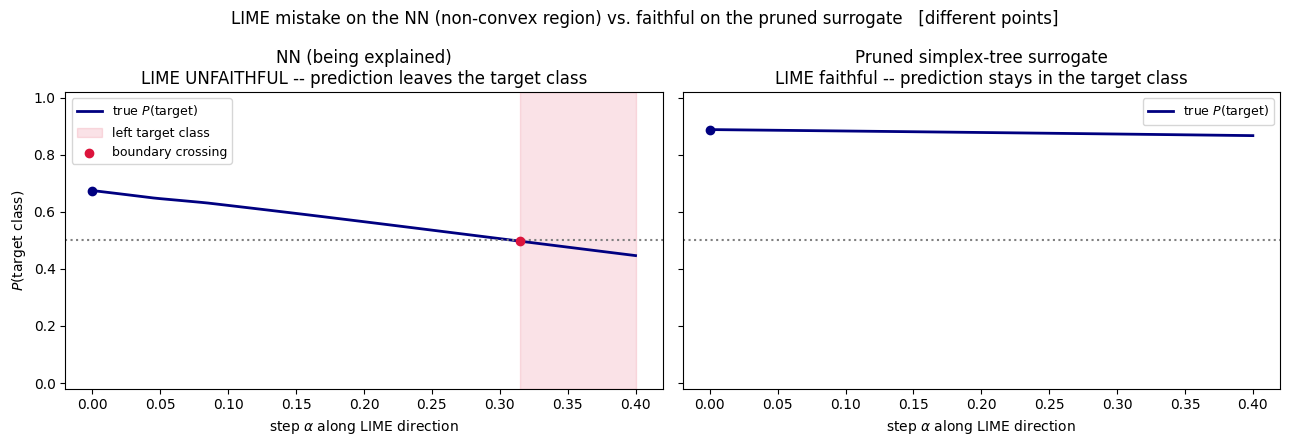

model                            start     min     end   verdict
----------------------------------------------------------------
NN (being explained)             0.675   0.447   0.447   UNFAITHFUL (leaves target)
Pruned simplex-tree surrogate    0.889   0.867   0.867   faithful (stays)


In [15]:
if x0_nn is None:
    print('No NN demo point to plot.')
else:
    panels = [('NN (being explained)', nn_proba, x0_nn)]
    if x0_stc is not None:
        panels.append(('Pruned simplex-tree surrogate', stc_proba, x0_stc))
    fig, axes = plt.subplots(1, len(panels), figsize=(6.5 * len(panels), 4.5), sharey=True)
    axes = np.atleast_1d(axes)
    summary = []
    for ax, (name, proba_fn, pt) in zip(axes, panels):
        a, f_t, _, tgt, _, _, am = push(pt, proba_fn)     # each panel uses its own model's target here
        crossed = crosses_boundary(am, tgt); xc = first_crossing(am, tgt)
        title = (f'{name}\nLIME UNFAITHFUL -- prediction leaves the target class'
                 if crossed else f'{name}\nLIME faithful -- prediction stays in the target class')
        ax.plot(a, f_t, color='navy', lw=2, label=r'true $P(\mathrm{target})$')
        off = np.asarray(am) != tgt
        if off.any():
            ax.fill_between(a, 0, 1, where=off, color='crimson', alpha=0.12,
                            transform=ax.get_xaxis_transform(), label='left target class')
        ax.axhline(0.5, color='gray', ls=':')
        ax.scatter([0], [f_t[0]], color='navy', zorder=5)
        if xc is not None:
            ax.scatter([a[xc]], [f_t[xc]], color='crimson', zorder=6, label='boundary crossing')
        ax.set_xlabel(r'step $\alpha$ along LIME direction'); ax.set_ylim(-0.02, 1.02)
        ax.set_title(title); ax.legend(loc='best', fontsize=9)
        summary.append((name, float(f_t[0]), float(f_t.min()), float(f_t[-1]), crossed))
    axes[0].set_ylabel(r'$P(\mathrm{target\ class})$')
    same = (x0_stc is not None) and np.array_equal(x0_stc, x0_nn)
    plt.suptitle('LIME mistake on the NN (non-convex region) vs. faithful on the pruned surrogate'
                 + ('   [same point]' if same else '   [different points]'))
    plt.tight_layout(); plt.show()

    hdr = f'{"model":30s} {"start":>7s} {"min":>7s} {"end":>7s}   verdict'
    print(hdr); print('-' * len(hdr))
    for name, s, mn, e, crossed in summary:
        verdict = 'UNFAITHFUL (leaves target)' if crossed else 'faithful (stays)'
        print(f'{name:30s} {s:>7.3f} {mn:>7.3f} {e:>7.3f}   {verdict}')